## tl;dr

- 这三组是 B1/Search-v2.1 上游重跑，**不是 B2-v3 refiner**。
- 新 Motion+Search-v2.1 final 为 **26.754 / 26.876**，闭环严重失败。
- 不运行 seed43/44；下一步是从严格 init 训练 cfg13 20 epochs。

## Context & Methods

分析单位为每个训练 run。Final=epoch60；Late-3=epoch50/55/60 算术均值。历史 B0 仅作 guardrail，因为当前 clean commit 没有 matched B0。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd()
validation = pd.read_csv(ROOT / r'compare_results/data/b2_v3_precursor_seed42_20260804_validation.csv')
summary = pd.read_csv(ROOT / r'compare_results/data/b2_v3_precursor_seed42_20260804_summary.csv')
diagnostics = pd.read_csv(ROOT / r'compare_results/data/b2_v3_precursor_seed42_20260804_training_diagnostics.csv')
decisions = pd.read_csv(ROOT / r'compare_results/data/b2_v3_precursor_seed42_20260804_decisions.csv')
summary

,run_id,arm,role,final_success,final_precision,late3_success,late3_precision,best_success,best_success_epoch,best_precision,best_precision_epoch
0,B0_HIST,Historical B0,historical_guardrail,53.359955,64.381836,52.904814,63.104301,54.134571,50,64.381836,60
1,OLD_B1,Previous B1-motion-v3,previous_rerun,52.655365,61.834793,52.049966,61.206420,52.655365,60,65.555801,30
2,OLD_SEARCH,Previous Search-v2.1 only,previous_rerun,52.742886,63.045956,51.812183,61.767326,53.594093,40,64.493439,40
3,OLD_FULL,Previous Motion+Search-v2.1,previous_rerun,25.847923,25.177244,25.793219,25.365428,32.405907,10,32.247265,5
4,NEW_B1,New B1-motion-v3,requested_rerun,53.318382,62.573307,53.062365,62.512403,53.344643,45,66.727570,30
5,NEW_SEARCH,New Search-v2.1 only,requested_rerun,51.307442,59.816193,51.140411,60.115974,51.876373,50,63.332603,15
6,NEW_FULL,New Motion+Search-v2.1,requested_rerun,26.753830,26.876366,27.061636,27.041939,29.563457,5,29.862144,5


## Data

完整性与身份判断：

In [2]:
integrity = pd.read_csv(ROOT / r'compare_results/data/b2_v3_precursor_seed42_20260804_integrity.csv')
integrity

,run_id,config_path,commit,dirty,seed,train_split,val_split,optimizer_steps,validation_points,last_checkpoint_present,init_checkpoint,use_motion_conditioned_search_v3,use_action_consistent_router_v3
0,NEW_B1,cfgs/ct_v2/02_ct_motion_v3.yaml,73d6ce25682c19be6a70fcd95a125874deb306e8,False,42,mini_train,mini_val,75720,12,True,NaN,False,False
1,NEW_SEARCH,cfgs/ct_v2/08_seqtrack3d_search_v21.yaml,73d6ce25682c19be6a70fcd95a125874deb306e8,False,42,mini_train,mini_val,75720,12,True,NaN,False,False
2,NEW_FULL,cfgs/ct_v2/09_ct_motion_search_v21.yaml,73d6ce25682c19be6a70fcd95a125874deb306e8,False,42,mini_train,mini_val,75720,12,True,NaN,False,False


## Results

四条曲线展示历史 B0 guardrail 与三条新重跑。

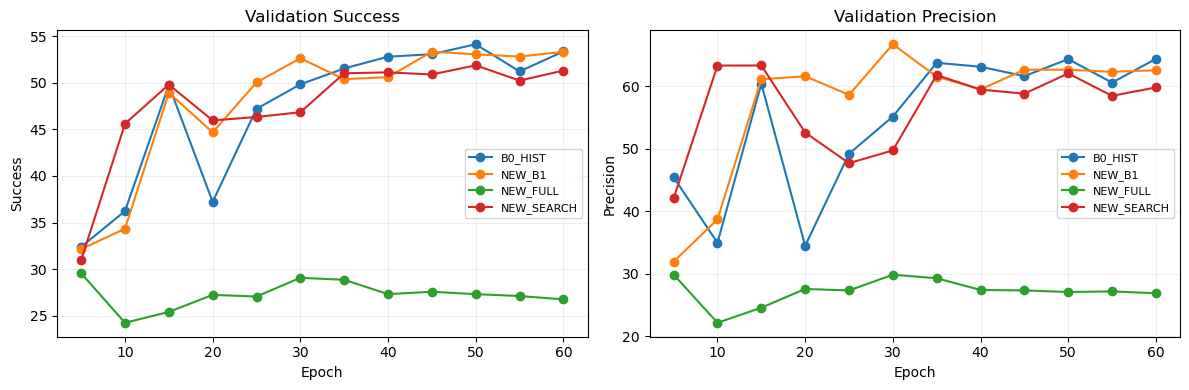

In [3]:
visible = validation[validation.run_id.isin(['B0_HIST','NEW_B1','NEW_SEARCH','NEW_FULL'])]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for run_id, frame in visible.groupby('run_id'):
    axes[0].plot(frame.epoch, frame.success, marker='o', label=run_id)
    axes[1].plot(frame.epoch, frame.precision, marker='o', label=run_id)
axes[0].set(title='Validation Success', xlabel='Epoch', ylabel='Success')
axes[1].set(title='Validation Precision', xlabel='Epoch', ylabel='Precision')
for axis in axes:
    axis.grid(alpha=.2); axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [4]:
full = diagnostics[(diagnostics.run_id == 'NEW_FULL') & diagnostics.metric.isin(['observation_error','motion_error_valid','search_error_valid','final_error'])][['metric','epoch60_mean']]
full

,metric,epoch60_mean
17,observation_error,0.247833
18,motion_error_valid,0.269888
19,search_error_valid,0.245699
20,final_error,0.229717


In [5]:
decisions

,check,criterion,observed,status,interpretation
0,NEW_B1_historical_b0_gain,+0.5 Success and +1.0 Precision at epoch60,-0.042 S / -1.809 P,failed,Historical guardrail only; a same-commit B0 is...
1,NEW_SEARCH_historical_b0_gain,+0.5 Success and +1.0 Precision at epoch60,-2.053 S / -4.566 P,failed,Historical guardrail only; a same-commit B0 is...
2,NEW_FULL_historical_b0_gain,+0.5 Success and +1.0 Precision at epoch60,-26.606 S / -37.505 P,failed,Historical guardrail only; a same-commit B0 is...
3,b2_v3_identity,Config13 refiner checkpoint with V3 path enabled,All three runs use configs 02/08/09; V3 flags ...,failed,"These are precursor/ablation runs, not B2-v3."
4,offline_to_closed_loop_transfer,Offline candidate improvement transfers to tra...,NEW_FULL epoch60 offline final error 0.230 vs ...,failed,One-step training diagnostics do not transfer ...
5,b2_v3_promotion_gate,Candidate RMSE + calibration + mini_val obs_vs...,"No config13 epoch20 diagnostics, rollout route...",not_run,B2-v3 success cannot yet be evaluated.


## Takeaways

1. 当前没有训练完成的 B2-v3，不能宣称 V3 成功或涨点。
2. Search 候选会学习，但 v2.1 full 的 one-step 改善未转化为递归 tracking。
3. 下一步应进入 cfg13→两轮 rollout→最终 router/package，而不是再重跑 cfg09。